**MK Rekayasa Fitur**

**Topik:** Ekstraksi Fitur

* **Teknik Manual dan Berbasis Filter - Data Gambar**

**Galih Hermawan. Prodi Teknik Informatika. UNIKOM**

---


Membuat Gambar 9 Ubin Warna warni

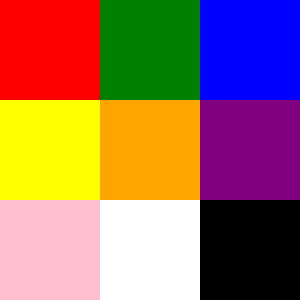

In [1]:
from PIL import Image, ImageDraw
from IPython.display import display 

ukuran_gambar = 300
ukuran_ubin = ukuran_gambar // 3

warna_ubin = ['red', 'green', 'blue', 'yellow', 'orange', 'purple', 'pink', 'white', 'black']

gambar = Image.new('RGB', (ukuran_gambar, ukuran_gambar), 'grey')
tulis_gambar = ImageDraw.Draw(gambar)

for i, warna in enumerate(warna_ubin):
    x = (i % 3) * ukuran_ubin
    y = (i // 3) * ukuran_ubin
    tulis_gambar.rectangle([x, y, x + ukuran_ubin, y + ukuran_ubin], fill=warna)

# Buka tanda komentar ini jika ingin menyimpan fail gambar dan menampilkan di aplikasi default
#gambar.save('ubin_warna.png')
#gambar.show()

# menampilkan gambar di cell
display(gambar)

Memeriksa nilai piksel pada ubin

In [2]:
gbr = Image.open('ubin_warna.png')

lebar, tinggi = gbr.size

# menampilkan nilai warna piksel di setiap titik piksel ** WARNING ** nilai sebanyak 300x300
"""
for y in range(tinggi):
    for x in range(lebar):
        nilai_piksel = gbr.getpixel((x, y))
        merah, hijau, biru = nilai_piksel
        print(merah, hijau, biru)
"""

# menampilkan nilai piksel di koordinat (titik piksel tertentu)
print(gbr.getpixel((0, 0))) # area ubin merah
print(gbr.getpixel((100, 0))) # area ubin hijau
print(gbr.getpixel((200, 0))) # area ubin biru
print(gbr.getpixel((200, 200))) # area ubin hitam

(255, 0, 0)
(0, 128, 0)
(0, 0, 255)
(0, 0, 0)


Mengubah warna ubin ke Keabuan. <br>
Nilai skala abu-abu (luminance) = 0,299xRed + 0,587xGreen + 0,114xBlue

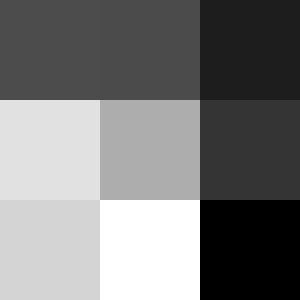

In [3]:
for y in range(tinggi):
    for x in range(lebar):
        nilai_piksel = gbr.getpixel((x, y))
        merah, hijau, biru = nilai_piksel
        abu_abu = int(0.299*merah + 0.587*hijau + 0.114*biru)
        gbr.putpixel((x,y),(abu_abu, abu_abu, abu_abu))
        
# Buka tanda komentar ini jika ingin menyimpan fail gambar dan menampilkan di aplikasi default
#gbr.save('ubin_abu.png')
#gbr.show()

display(gbr)

Mengubah gambar warna ke hitam putih

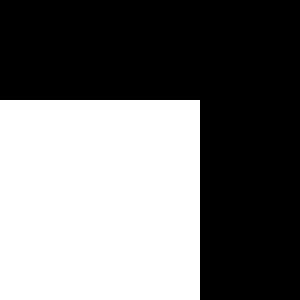

In [4]:
gbr = Image.open('ubin_warna.png')

lebar, tinggi = gbr.size

# Tentukan ambang batas
batas_ambang = 128  # Nilai ini bisa diubah sesuai kebutuhan

for y in range(tinggi):
    for x in range(lebar):
        nilai_piksel = gbr.getpixel((x, y))
        merah, hijau, biru = nilai_piksel
        abu_abu = int(0.299*merah + 0.587*hijau + 0.114*biru)
        hitam_putih = 255 if abu_abu > batas_ambang else 0
        gbr.putpixel((x, y), (hitam_putih, hitam_putih, hitam_putih))
        
# Buka tanda komentar ini jika ingin menyimpan fail gambar dan menampilkan di aplikasi default
#gbr.save('ubin_hitam_putih.png')
#gbr.show()

display(gbr)

<hr>
Menampilkan gambar Bunga, sekaligus hasil perubahan warna ke Keabuan dan Hitam Putih.

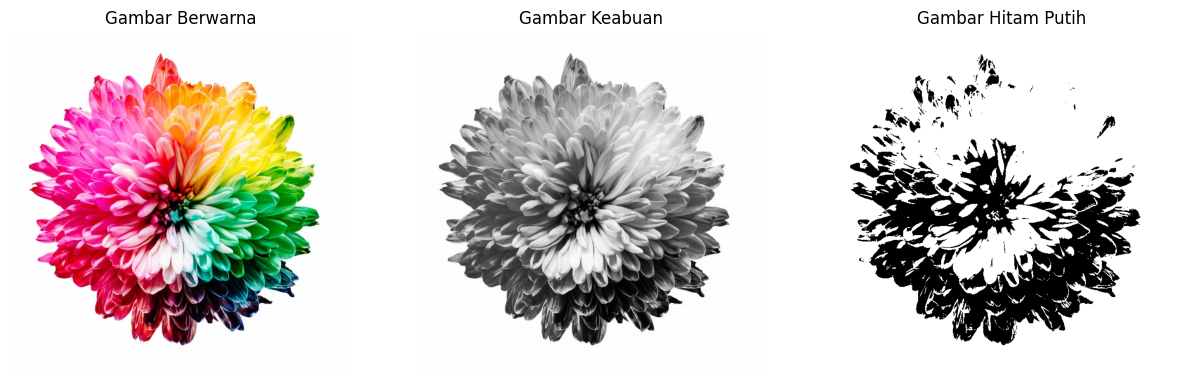

In [5]:
import matplotlib.pyplot as plt
from PIL import Image

# Buka gambar asli
gambar = Image.open('bunga.jpg')

# Konversi ke greyscale
gambar_abu_abu = gambar.convert('L')

# Konversi ke hitam putih dengan ambang batas
batas_ambang = 128
gambar_hitam_putih = gambar_abu_abu.point(lambda x: 255 if x > batas_ambang else 0, '1')

# Menyiapkan subplot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Menampilkan gambar asli
axes[0].imshow(gambar)
axes[0].set_title('Gambar Berwarna')
axes[0].axis('off')  # Matikan sumbu

# Menampilkan gambar keabuan (greyscale)
axes[1].imshow(gambar_abu_abu, cmap='gray')
axes[1].set_title('Gambar Keabuan')
axes[1].axis('off')

# Menampilkan gambar hitam putih
axes[2].imshow(gambar_hitam_putih, cmap='gray')
axes[2].set_title('Gambar Hitam Putih')
axes[2].axis('off')

# Menampilkan semua subplot
plt.show()


**Teknik Manual untuk Menandai Suatu Obyek dan Menghitungnya**

In [2]:
import cv2

# Fungsi untuk membaca gambar dan menandai kotak pada gambar
def annotasi_mobil(gambar):
    # Salin gambar agar tidak merubah gambar asli
    gambar_annotasi = gambar.copy()
    
    # Membuat window OpenCV untuk menampilkan gambar dan menanggapi input mouse
    cv2.namedWindow('Annotasi Mobil')
    cv2.setMouseCallback('Annotasi Mobil', annotasi_mouse_handler)

    # Variabel global untuk menyimpan koordinat kotak yang ditandai
    global titik_awal, sedang_menandai, kotak

    titik_awal = None
    sedang_menandai = False
    kotak = []

    # Loop untuk menunggu input dari mouse
    while True:
        # Tampilkan gambar dengan kotak yang ditandai
        for (x1, y1, x2, y2) in kotak:
            cv2.rectangle(gambar_annotasi, (x1, y1), (x2, y2), (0, 255, 0), 2)

        cv2.imshow('Annotasi Mobil', gambar_annotasi)

        # Tunggu tombol kunci 'q' ditekan untuk keluar
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cv2.destroyAllWindows()

# Fungsi handler untuk menangani input mouse saat menandai kotak
def annotasi_mouse_handler(event, x, y, flags, param):
    global titik_awal, sedang_menandai, kotak

    # Jika tombol kiri mouse ditekan, catat koordinat titik awal
    if event == cv2.EVENT_LBUTTONDOWN:
        titik_awal = (x, y)
        sedang_menandai = True

    # Jika tombol kiri mouse dilepas, hitung koordinat akhir dan tambahkan kotak ke daftar kotak
    elif event == cv2.EVENT_LBUTTONUP and sedang_menandai:
        kotak.append((titik_awal[0], titik_awal[1], x, y))
        sedang_menandai = False

        # Hitung dan tampilkan jumlah kotak yang ditandai
        print("Jumlah mobil yang ditandai:", len(kotak))

# Baca gambar
lokasi_gambar = 'mobil_3.jpg'
gambar = cv2.imread(lokasi_gambar)

# Annotasi mobil dalam gambar
annotasi_mobil(gambar)


Jumlah mobil yang ditandai: 1
Jumlah mobil yang ditandai: 2
Jumlah mobil yang ditandai: 3
Jumlah mobil yang ditandai: 4


---

***Menandai Sekaligus Menyimpan Potongan Gambar**

In [7]:
import cv2
import os

# Fungsi untuk membaca gambar dan menandai kotak pada gambar
def annotasi_mobil(gambar):
    # Salin gambar agar tidak merubah gambar asli
    gambar_annotasi = gambar.copy()
    
    # Membuat window OpenCV untuk menampilkan gambar dan menanggapi input mouse
    cv2.namedWindow('Annotasi Mobil')
    cv2.setMouseCallback('Annotasi Mobil', annotasi_mouse_handler)

    # Variabel global untuk menyimpan koordinat kotak yang ditandai
    global titik_awal, sedang_menandai, kotak, counter

    titik_awal = None
    sedang_menandai = False
    kotak = []
    counter = 1

    # Loop untuk menunggu input dari mouse
    while True:
        # Tampilkan gambar dengan kotak yang ditandai
        for (x1, y1, x2, y2) in kotak:
            cv2.rectangle(gambar_annotasi, (x1, y1), (x2, y2), (0, 255, 0), 2)

        cv2.imshow('Annotasi Mobil', gambar_annotasi)

        # Tunggu tombol kunci 'q' ditekan untuk keluar
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cv2.destroyAllWindows()

# Fungsi handler untuk menangani input mouse saat menandai kotak
def annotasi_mouse_handler(event, x, y, flags, param):
    global titik_awal, sedang_menandai, kotak, counter

    # Jika tombol kiri mouse ditekan, catat koordinat titik awal
    if event == cv2.EVENT_LBUTTONDOWN:
        titik_awal = (x, y)
        sedang_menandai = True

    # Jika tombol kiri mouse dilepas, hitung koordinat akhir dan tambahkan kotak ke daftar kotak
    elif event == cv2.EVENT_LBUTTONUP and sedang_menandai:
        kotak.append((titik_awal[0], titik_awal[1], x, y))
        sedang_menandai = False

        # Hitung dan tampilkan jumlah kotak yang ditandai
        print("Jumlah mobil yang ditandai:", len(kotak))

        # Potong dan simpan potongan gambar obyek sebagai gambar terpisah
        potong_gambar(gambar, kotak[-1], counter)
        counter += 1

# Fungsi untuk memotong dan menyimpan potongan gambar obyek sebagai gambar terpisah
def potong_gambar(gambar, kotak, counter):
    x1, y1, x2, y2 = kotak
    potongan = gambar[y1:y2, x1:x2]
    cv2.imwrite(f'potongan_mobil_{counter}.jpg', potongan)
    print(f"Potongan gambar mobil {counter} disimpan.")

# Baca gambar
lokasi_gambar = 'mobil_3.jpg'
gambar = cv2.imread(lokasi_gambar)

# Annotasi mobil dalam gambar
annotasi_mobil(gambar)


Jumlah mobil yang ditandai: 1
Potongan gambar mobil 1 disimpan.


<hr>

Beberapa teknik ekstraksi fitur sederhana yang dapat digunakan untuk menganalisis gambar adalah sebagai berikut:

1. <b>Histogram Warna:</b> Histogram warna adalah salah satu fitur yang paling sederhana tetapi informatif dalam analisis gambar. Ini memberikan distribusi intensitas piksel berdasarkan komponen warna tertentu (misalnya, RGB atau HSV). Dengan menganalisis histogram warna, Anda dapat mengetahui distribusi warna dalam gambar, yang dapat berguna untuk klasifikasi atau pengenalan objek.

2. <b>Bentuk dan Ukuran:</b> Fitur-fitur geometris seperti bentuk dan ukuran objek dalam gambar juga dapat diekstraksi secara sederhana. Misalnya, Anda dapat menghitung area, perimeter, atau perbandingan aspek objek untuk mendapatkan informasi tentang geometri objek.

3. <b>Tekstur:</b> Fitur tekstur merangkum pola tekstur yang ada dalam gambar. Ini bisa mencakup statistik sederhana seperti mean, variance, atau energi dari matriks tekstur seperti matriks co-occurrence gray-level atau filter Gabor untuk mendapatkan informasi tentang tekstur dalam gambar.

4. <b>Histogram Grayscale:</b> Histogram grayscale memberikan distribusi intensitas piksel dalam gambar secara keseluruhan. Ini dapat memberikan wawasan tentang tingkat kecerahan dan kontras gambar.

---

**EKSTRAKSI FITUR - TEKNIK BERBASIS FILTER**

**Contoh Kasus: Mendeteksi Fitur Tepi/Guratan Gambar (deteksi tepi)**

<b>Deteksi Tepi</b> adalah proses mengidentifikasi lokasi di dalam citra di mana intensitas citra berubah secara signifikan. Teknik ini sering digunakan untuk menemukan batas objek dalam citra. Deteksi tepi biasanya melibatkan penggunaan operator gradien untuk mengukur perubahan intensitas dan dapat dilakukan dengan berbagai metode, seperti Sobel, Prewitt, atau Canny.

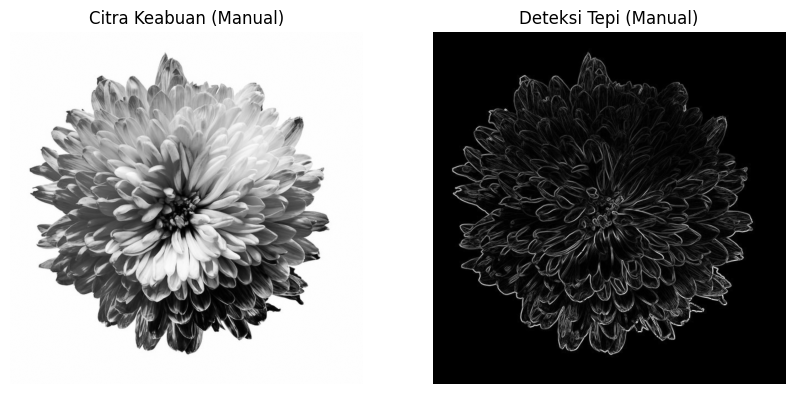

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Fungsi untuk menampilkan kedua gambar dalam satu bingkai
def tampilkan_gambar(gambar1, judul1, gambar2, judul2):
    plt.figure(figsize=(10, 5))
    
    plt.subplot(1, 2, 1)
    plt.imshow(gambar1, cmap='gray')
    plt.title(judul1)
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(gambar2, cmap='gray')
    plt.title(judul2)
    plt.axis('off')
    
    plt.show()

# Baca gambar
lokasi_gambar = 'bunga.jpg'
gambar = cv2.imread(lokasi_gambar)

# Konversi ke citra keabuan secara manual
keabuan_manual = cv2.cvtColor(gambar, cv2.COLOR_BGR2GRAY)

# Konversi tipe data ke int32
keabuan_manual = keabuan_manual.astype(np.int32)

# Deteksi tepi secara manual dengan perbedaan intensitas piksel
tepian_manual = np.zeros_like(keabuan_manual, dtype=np.uint8)

for i in range(1, keabuan_manual.shape[0] - 1):
    for j in range(1, keabuan_manual.shape[1] - 1):
        gx = keabuan_manual[i, j+1] - keabuan_manual[i, j-1]
        gy = keabuan_manual[i+1, j] - keabuan_manual[i-1, j]
        tepian_manual[i, j] = np.sqrt(gx**2 + gy**2)

# Tampilkan kedua gambar dalam satu bingkai
tampilkan_gambar(keabuan_manual, "Citra Keabuan (Manual)", tepian_manual, "Deteksi Tepi (Manual)")


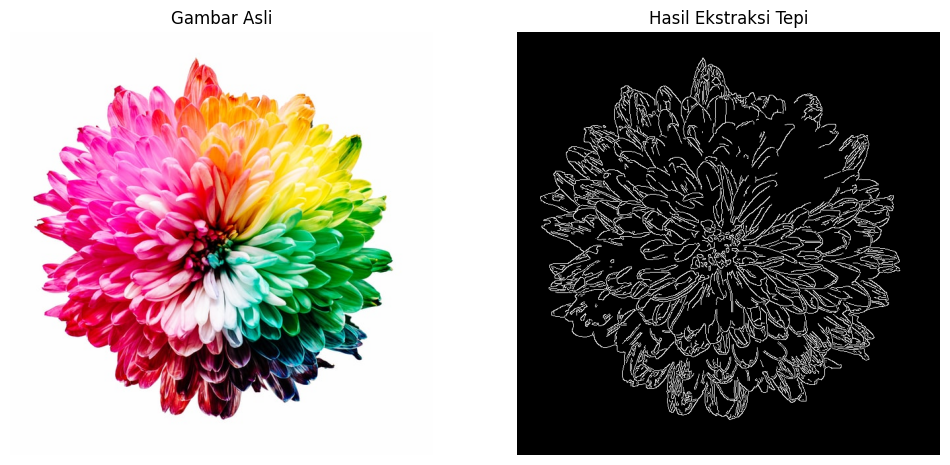

In [9]:
import cv2
from matplotlib import pyplot as plt

# Step 1: Baca Gambar
fail_gambar = 'bunga.jpg'
gambar = cv2.imread(fail_gambar)

# Step 2: Konversi ke Grayscale
gambar_abu_abu = cv2.cvtColor(gambar, cv2.COLOR_BGR2GRAY)

# Step 3: Ekstraksi Fitur Tepi
tepi_gambar = cv2.Canny(gambar_abu_abu, 100, 200)  # Parameter 100 dan 200 adalah batas bawah dan atas untuk deteksi tepi

# Step 4: Tampilkan Gambar Hasil
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(gambar, cv2.COLOR_BGR2RGB))
plt.title('Gambar Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(tepi_gambar, cmap='gray')
plt.title('Hasil Ekstraksi Tepi')
plt.axis('off')

plt.show()
